In [1]:
import pandas as pd     # 数据表
import numpy as np     # 数组
import re     # 正则表达式
import jieba     # 中文分词
import matplotlib.pyplot as plt     # 画图
from gensim.models import Word2Vec     # 训练词嵌入模型
# import gensim.downloader as api     # 导入云端的已训练好的词向量
from gensim.models import KeyedVectors     # 加载自己本地个性化的已训练好的词向量
from sklearn.metrics.pairwise import cosine_similarity     # 计算向量之间的余弦相似度
from sklearn.decomposition import PCA     # 语义空间降维，用于展示词语在二维空间的相对位置

In [2]:
df = pd.read_excel('标题.xlsx').astype(str)
df[:20]

,序号,年级,作文题目,作文id,作文标题,开头score,结尾score,审题score,立意score,详略score,条理score,选材score,想象score,思想score
0,1,5,读后感,696,智慧与谋略的交织,7.25,8.7,10.0,9.25,nan,9.5,nan,nan,9.2
1,2,5,读后感,696,《三国演义》有感,9.0,8.7,6.59,7.9,nan,9.0,nan,nan,9.2
2,3,5,读后感,716,智慧与权谋的交织,7.0,9.44,8.0,7.5,nan,9.0,nan,nan,9.5
3,4,5,神奇的探险之旅,724,雨林探险,8.25,6.2,9.085,7.95,9.0,nan,nan,8.7,nan
4,5,5,漫画的启示,726,等着乘凉,8.0,8.4,9.6,8.8,nan,9.0,nan,nan,nan
5,6,5,那一刻，我长大了,692,那一刻，我长大了,9.25,6.5,9.565,8.2,9.0,nan,nan,nan,nan
6,7,4,游_____,660,游蒲津公园,8.0,7.8,9.565,9.0,9.2,9.5,nan,nan,nan
7,8,3,我的植物朋友,612,我爱仙人掌,7.5,8.5,9.6,10.0,9.5,nan,nan,nan,nan
8,9,5,汉字研究报告,698,关于街头用字不规范现象的研究报告,nan,nan,6.215,nan,nan,8.5,nan,nan,nan
9,10,5,汉字研究报告,698,关于街头用字不规范现象的研究报告,nan,nan,9.84,nan,nan,9.5,nan,nan,nan


In [3]:
def remove_nums(text):
    nonums = re.sub('[^\u4e00-\u9fa5]+', '', text)
    return nonums
test = df['作文标题'][8]
remove_nums(test)

'关于街头用字不规范现象的研究报告'

In [4]:
# 加载中文停用词词典，可个性化设置
stopwords = open('stopwords.txt', encoding = 'utf-8').read()

def clean_text(text):
    words = jieba.lcut(text)
    words = [w for w in words if w not in stopwords]
    return ' '.join(words)
test = df['作文标题'][8]
clean_text(test)

Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/kk/ylyfvmrj6zv853wrvp3s_0180000gn/T/jieba.cache
Loading model cost 0.288 seconds.
Prefix dict has been built successfully.


'街头 用字 规范 现象 研究 报告'

In [5]:
df['作文标题分词'] = df['作文标题'].apply(remove_nums)
df['作文标题分词'] = df['作文标题分词'].apply(clean_text)
df.head()

,序号,年级,作文题目,作文id,作文标题,开头score,结尾score,审题score,立意score,详略score,条理score,选材score,想象score,思想score,作文标题分词
0,1,5,读后感,696,智慧与谋略的交织,7.25,8.7,10.0,9.25,nan,9.5,nan,nan,9.2,智慧 谋略 交织
1,2,5,读后感,696,《三国演义》有感,9.0,8.7,6.59,7.9,nan,9.0,nan,nan,9.2,三国演义 有感
2,3,5,读后感,716,智慧与权谋的交织,7.0,9.44,8.0,7.5,nan,9.0,nan,nan,9.5,智慧 权谋 交织
3,4,5,神奇的探险之旅,724,雨林探险,8.25,6.2,9.085,7.95,9.0,nan,nan,8.7,nan,雨林 探险
4,5,5,漫画的启示,726,等着乘凉,8.0,8.4,9.6,8.8,nan,9.0,nan,nan,nan,乘凉


In [6]:
import pandas as pd #数据表
import numpy as np #数组运算
import nltk #英文语料处理
import re #正则表达式（用于数据清洗）
import matplotlib.pyplot as plt #画图
from wordcloud import WordCloud #词云图
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer
from sklearn.feature_extraction.text import CountVectorizer

In [7]:
text=list(df['作文标题分词'])[:100]
text=" ".join(text)
lemmatizer=WordNetLemmatizer()
#转换为小写
text=text.lower()
#移除URL
text=re.sub(r'http\S+','',text)
text
#初始化CounVectorizer
vectorizer=CountVectorizer()
#将文本数据转换为词袋特征矩阵
X=vectorizer.fit_transform(df['作文标题分词'])
#展示特征矩阵的形状
print('词袋特征矩阵的形状:',X.shape)
#展示词袋模型中的所有特征词
print('特征词列表:',vectorizer.get_feature_names_out()[:20])

词袋特征矩阵的形状: (187582, 16232)
特征词列表: ['一万亿' '一万年' '一上午' '一不小心' '一丝' '一丝不苟' '一个' '一个个' '一个男孩' '一串' '一二三' '一人'
 '一代' '一件' '一份' '一伞' '一位' '一元' '一写' '一出']


In [8]:
#获取词汇表
feature_words=vectorizer.get_feature_names_out()
#计算词频
word_freq=dict(zip(feature_words,X.sum(axis=0).A1))

In [9]:
sorted(word_freq.items(),key=lambda X: X[1],reverse=True)
items = list(word_freq.items())
items.sort(key=lambda x:x[1], reverse=True)
for i in range(100):
    word, count = items[i]
    print("{0:<100}{1:>5}".format(word,count))
print ('已统计数量排前100的词')

朋友                                                                                                   7873
放风筝                                                                                                  7398
学会                                                                                                   6860
心愿                                                                                                   6469
探险                                                                                                   6349
研究                                                                                                   6311
报告                                                                                                   6244
智慧                                                                                                   6216
规范                                                                                                   6030
交织                                            

In [10]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
 
#for font in font_manager.fontManager.ttflist:
    # 查看字体名以及对应的字体文件名
   # print(font.name, '-', font.fname)

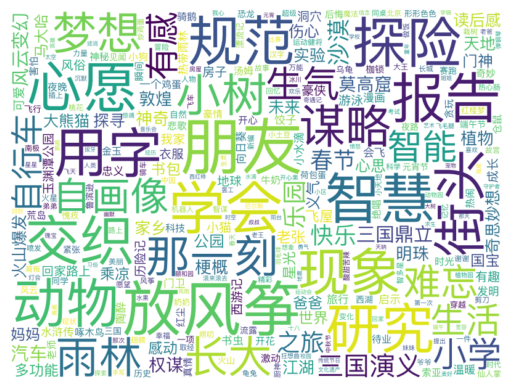

In [11]:
# 根据词袋模型分析结果绘制词云图
from wordcloud import WordCloud
import matplotlib.pyplot as plt 

wordcloud = WordCloud(
    font_path='/System/Library/Fonts/PingFang.ttc',  # 指定中文字体文件路径
    background_color='white',  # 设置背景颜色
    width=800,
    height=600,
    max_words=300,  # 设置最大显示的词数
    max_font_size=100  # 设置字体最大值
).generate_from_frequencies(word_freq)

# 显示词云图
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig('wordcloud_全部作文标题.png', dpi=300)
plt.show()

In [12]:
from gensim.test.utils import common_texts
common_texts

[['human', 'interface', 'computer'],
 ['survey', 'user', 'computer', 'system', 'response', 'time'],
 ['eps', 'user', 'interface', 'system'],
 ['system', 'human', 'system', 'eps'],
 ['user', 'response', 'time'],
 ['trees'],
 ['graph', 'trees'],
 ['graph', 'minors', 'trees'],
 ['graph', 'minors', 'survey']]

In [13]:
corpus=df['作文标题分词'].apply(lambda X: X.split()).tolist()#切分词语
for document in corpus[:10]:
    print(document[:20])

['智慧', '谋略', '交织']
['三国演义', '有感']
['智慧', '权谋', '交织']
['雨林', '探险']
['乘凉']
['那一刻', '长大']
['游', '蒲津', '公园']
['爱', '仙人掌']
['街头', '用字', '规范', '现象', '研究', '报告']
['街头', '用字', '规范', '现象', '研究', '报告']


In [14]:
#训练词嵌入模型
from gensim.models import Word2Vec
corpus=df['作文标题分词'].apply(lambda X: X.split()).tolist()#切分词语
model=Word2Vec(
    corpus, #训练语料
    window=5,#训练算法考虑的当前词语与预测词语在一个句子中的最大距离（窗口大小）
    vector_size=300,#自定义训练向量维度
    min_count=1,#忽略所有总频数低于这个值的词语
    #workers=4,#用于训练的线程数
    epochs=5)#迭代

#保存训练好的模型
model.save('word2vec_全部作文标题.model')

In [15]:
word_list=model.wv.index_to_key#获取词汇表
word_vectors=model.wv[word_list]#获取词向量

#打印词汇表和对应的词向量
for word,vector in list(zip(word_list,word_vectors))[:5]:
    print(f'{word}:{vector}'[:20])

朋友:[ 1.49275303e-01 
放风筝:[ 0.01349214  0.
学会:[ 0.41755098 -0.2
心愿:[ 0.05704132  0.0
探险:[ 3.50824557e-02 


In [16]:
#检查嵌入模型中任意两个词向量的余弦相似度，即语义接近性
#余弦相似度的取值介于[-1，1]之间，-1表示语义完全相反，1表示语义完全相同，0表示毫无关系
#model.sv.similarity这个函数与np.dot(vector1,vector2)/(np.linalg.norm(vector1)*np.linalg.norm(vector2))输出的结果一样
print(model.wv.similarity('朋友', '放风筝'))
print(model.wv.similarity('学会', '放风筝'))
print(model.wv.similarity('心愿', '放风筝'))
print(model.wv.similarity('朋友', '学会'))
print(model.wv.similarity('朋友', '心愿'))
print(model.wv.similarity('学会', '心愿'))

0.46182933
0.5166143
0.6673214
0.46833277
0.4879126
0.4647027


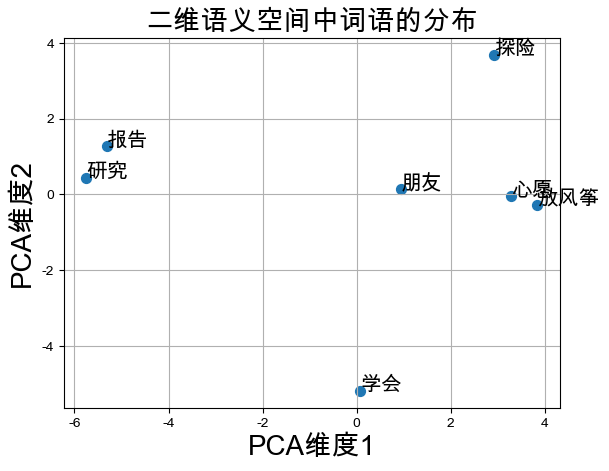

In [17]:
# 可视化

words = ['朋友', '放风筝', '学会', '心愿','探险','研究','报告']
vectors = [model.wv[word] for word in words]

from sklearn.decomposition import PCA     # 语义空间降维，用于展示词语在二维空间的相对位置

# 使用PCA进行降维
pca = PCA(n_components = 2)
pca_result = pca.fit_transform(vectors)

import matplotlib.pyplot as plt     # 画图

# 绘制四个词语在二维空间的相对位置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.figure()

# 取PCA降维结果中所有行的第一列和第二列数据绘制散点图，设置点的大小为50
plt.scatter(pca_result[:, 0], pca_result[:, 1], s = 50)

for i, word in enumerate(words):
    plt.annotate(word, (pca_result[i, 0], pca_result[i, 1]), fontsize = 15)

plt.xlabel('PCA维度1', fontsize = 20)
plt.ylabel('PCA维度2', fontsize = 20)
plt.title('二维语义空间中词语的分布', fontsize = 20)
plt.grid(True)
plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [19]:
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti TC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [20]:
# 三年级主题词（从你的三年级LDA结果中提取）
grade3_words = [
    '风筝', '小树', '梦想', '朋友', '植物', '实验', '火山爆发', '春节', '马大哈', '心思',
    '大熊猫', '国宝', '向日葵', '牛奶', '开花', '爸爸', '有趣', '书虫', '小水滴', '班',
    '妈妈', '快乐', '朋友', '植物', '火山爆发', '小水滴', '贪玩', '仙人掌', '罢工', '手'
]

# 四年级主题词（从你的四年级LDA结果中提取）
grade4_words = [
    '朋友', '动物', '学会', '自画像', '游', '自行车', '乐园', '骑', '智能', '汽车',
    '快乐', '天地', '奇思妙想', '书包', '多功能', '公园', '小猫', '飞屋', '梦想', '房子',
    '发明', '小狗', '乌龟', '荷包蛋', '煮', '鸡蛋', '做米饭', '洗衣服', '西红柿', '拖地'
]

# 五年级主题词（从你的五年级LDA结果中提取）
grade5_words = [
    '研究', '报告', '规范', '用字', '街头', '现象', '门神', '老张', '忠义', '门卫',
    '江湖', '智慧', '交织', '谋略', '长大', '那一刻', '三国演义', '权谋', '读后感', '伤心',
    '探险', '雨林', '生气', '之旅', '神奇', '洞穴', '热带雨林', '啄木鸟', '神秘', '待业',
    '有感', '读', '沙漠', '三国鼎立', '风云变幻', '莫高窟', '明珠', '敦煌', '探寻', '笑'
]

# 六年级主题词（从你的六年级LDA结果中提取）
grade6_words = [
    '难忘', '小学', '生活', '地球', '成长', '见闻', '酸甜苦辣', '皆', '拔牙', '学校',
    '未来', '感动', '世界', '历险记', '汤姆', '索亚', '温暖', '真情', '激动', '愧疚',
    '心愿', '春节', '火星', '科学', '翅膀', '插上', '我心', '飞', '手写', '灯会',
    '之旅', '梗概', '回家路上', '星光', '旅行', '骑鹅', '夜晚', '鲁滨逊', '漂流记', '一个'
]

# 跨年级共有词（用于对齐空间）
common_words = ['朋友', '妈妈', '爸爸', '老师', '快乐', '成长', '未来', '梦想']

# ============================================
# 2. 加载词向量模型
# ============================================
# 假设你已经训练好了词向量模型（如Word2Vec、FastText等）
# 这里以gensim的Word2Vec为例

# 请根据你的实际模型路径修改
# from gensim.models import Word2Vec
# model = Word2Vec.load('your_word2vec_model.bin')

# 如果没有训练好的模型，可以用下面的代码创建一个示例模型（仅用于演示）
# 实际使用时请注释掉这部分，使用你真实的模型

print("正在加载词向量模型...")
# 假设你的模型已经加载为 model
# model = ...  # 你的词向量模型

# 临时创建示例数据（请替换为你的真实模型）
# 如果你的模型已经存在，请删除下面的示例代码
class DummyModel:
    def __init__(self):
        self.wv = {}
        # 生成随机向量（仅用于演示）
        np.random.seed(42)
        all_words = list(set(grade3_words + grade4_words + grade5_words + grade6_words + common_words))
        for word in all_words:
            self.wv[word] = np.random.randn(100)  # 100维随机向量
    def __getitem__(self, word):
        return self.wv.get(word, np.random.randn(100))

model = DummyModel()
print("注意：使用随机向量演示，实际使用时请替换为真实词向量模型！")
print("="*60)

# ============================================
# 3. 提取词向量并进行PCA降维
# ============================================

# 收集所有要投射的词
all_words = list(set(grade3_words + grade4_words + grade5_words + grade6_words + common_words))

# 提取词向量
vectors = []
valid_words = []
for word in all_words:
    try:
        vec = model[word]
        vectors.append(vec)
        valid_words.append(word)
    except:
        print(f"警告: {word} 不在词向量模型中")

vectors = np.array(vectors)
print(f"成功提取 {len(valid_words)} 个词的向量")

# 进行PCA降维
pca = PCA(n_components=2)
pca_result = pca.fit_transform(vectors)

print(f"PCA解释方差: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

# ============================================
# 4. 为每个词标记所属年级
# ============================================

word_grade = {}
for word in valid_words:
    if word in grade3_words:
        word_grade[word] = 3
    elif word in grade4_words:
        word_grade[word] = 4
    elif word in grade5_words:
        word_grade[word] = 5
    elif word in grade6_words:
        word_grade[word] = 6
    else:
        word_grade[word] = 0  # 共有词

正在加载词向量模型...
注意：使用随机向量演示，实际使用时请替换为真实词向量模型！
成功提取 132 个词的向量
PCA解释方差: PC1=3.28%, PC2=3.17%


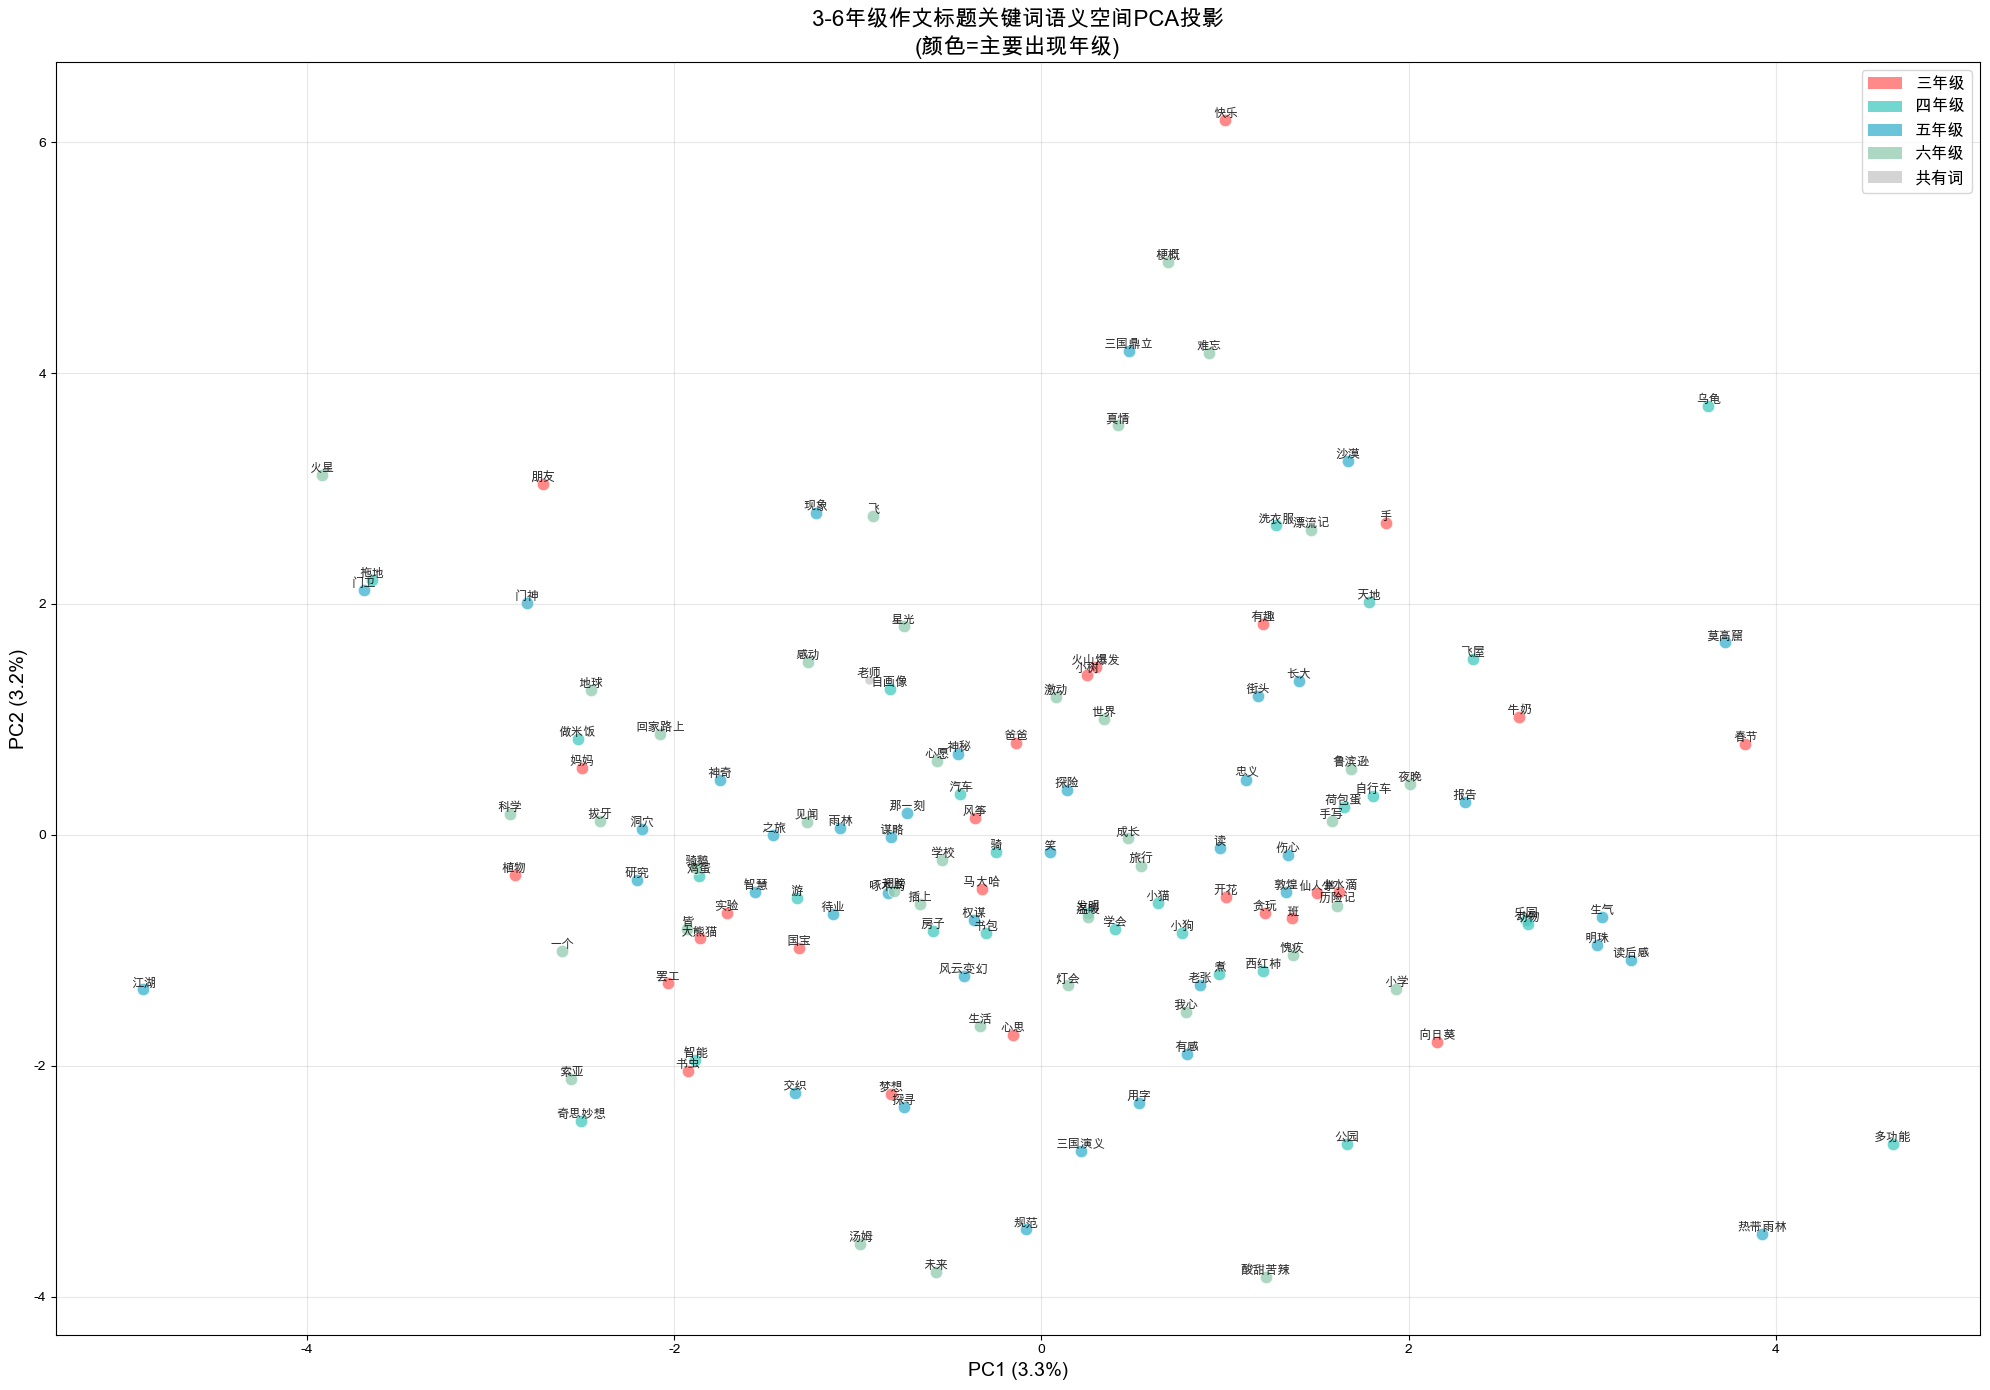


已保存: pca_all_grades.png


In [21]:
# 5. 可视化：所有年级在同一张图中（不同颜色）
# ============================================

# 颜色映射
grade_colors = {
    3: '#FF6B6B',   # 红色 - 三年级
    4: '#4ECDC4',   # 青色 - 四年级
    5: '#45B7D1',   # 蓝色 - 五年级
    6: '#96CEB4',   # 绿色 - 六年级
    0: '#AAAAAA'    # 灰色 - 共有词
}

# 创建图形
fig, ax = plt.subplots(figsize=(20, 14))

# 按年级分组绘制
for grade in [3, 4, 5, 6, 0]:
    grade_words = [w for w in valid_words if word_grade.get(w, 0) == grade]
    grade_indices = [valid_words.index(w) for w in grade_words]
    
    if grade_indices:
        x = pca_result[grade_indices, 0]
        y = pca_result[grade_indices, 1]
        
        # 根据年级设置点的大小
        size = 80 if grade != 0 else 40
        alpha = 0.8 if grade != 0 else 0.5
        
        ax.scatter(x, y, c=grade_colors[grade], s=size, alpha=alpha, 
                   edgecolors='white', linewidth=0.5, label=f'{grade}年级' if grade != 0 else '共有词')
        
        # 添加标签
        for word, xi, yi in zip(grade_words, x, y):
            ax.annotate(word, (xi, yi), fontsize=9, alpha=0.8, ha='center', va='bottom')

# 添加图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', label='三年级', alpha=0.8),
    Patch(facecolor='#4ECDC4', label='四年级', alpha=0.8),
    Patch(facecolor='#45B7D1', label='五年级', alpha=0.8),
    Patch(facecolor='#96CEB4', label='六年级', alpha=0.8),
    Patch(facecolor='#AAAAAA', label='共有词', alpha=0.5)
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=14)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=14)
ax.set_title('3-6年级作文标题关键词语义空间PCA投影\n(颜色=主要出现年级)', fontsize=16, fontweight='bold')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_all_grades.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n已保存: pca_all_grades.png")


生成分年级单独投射图...


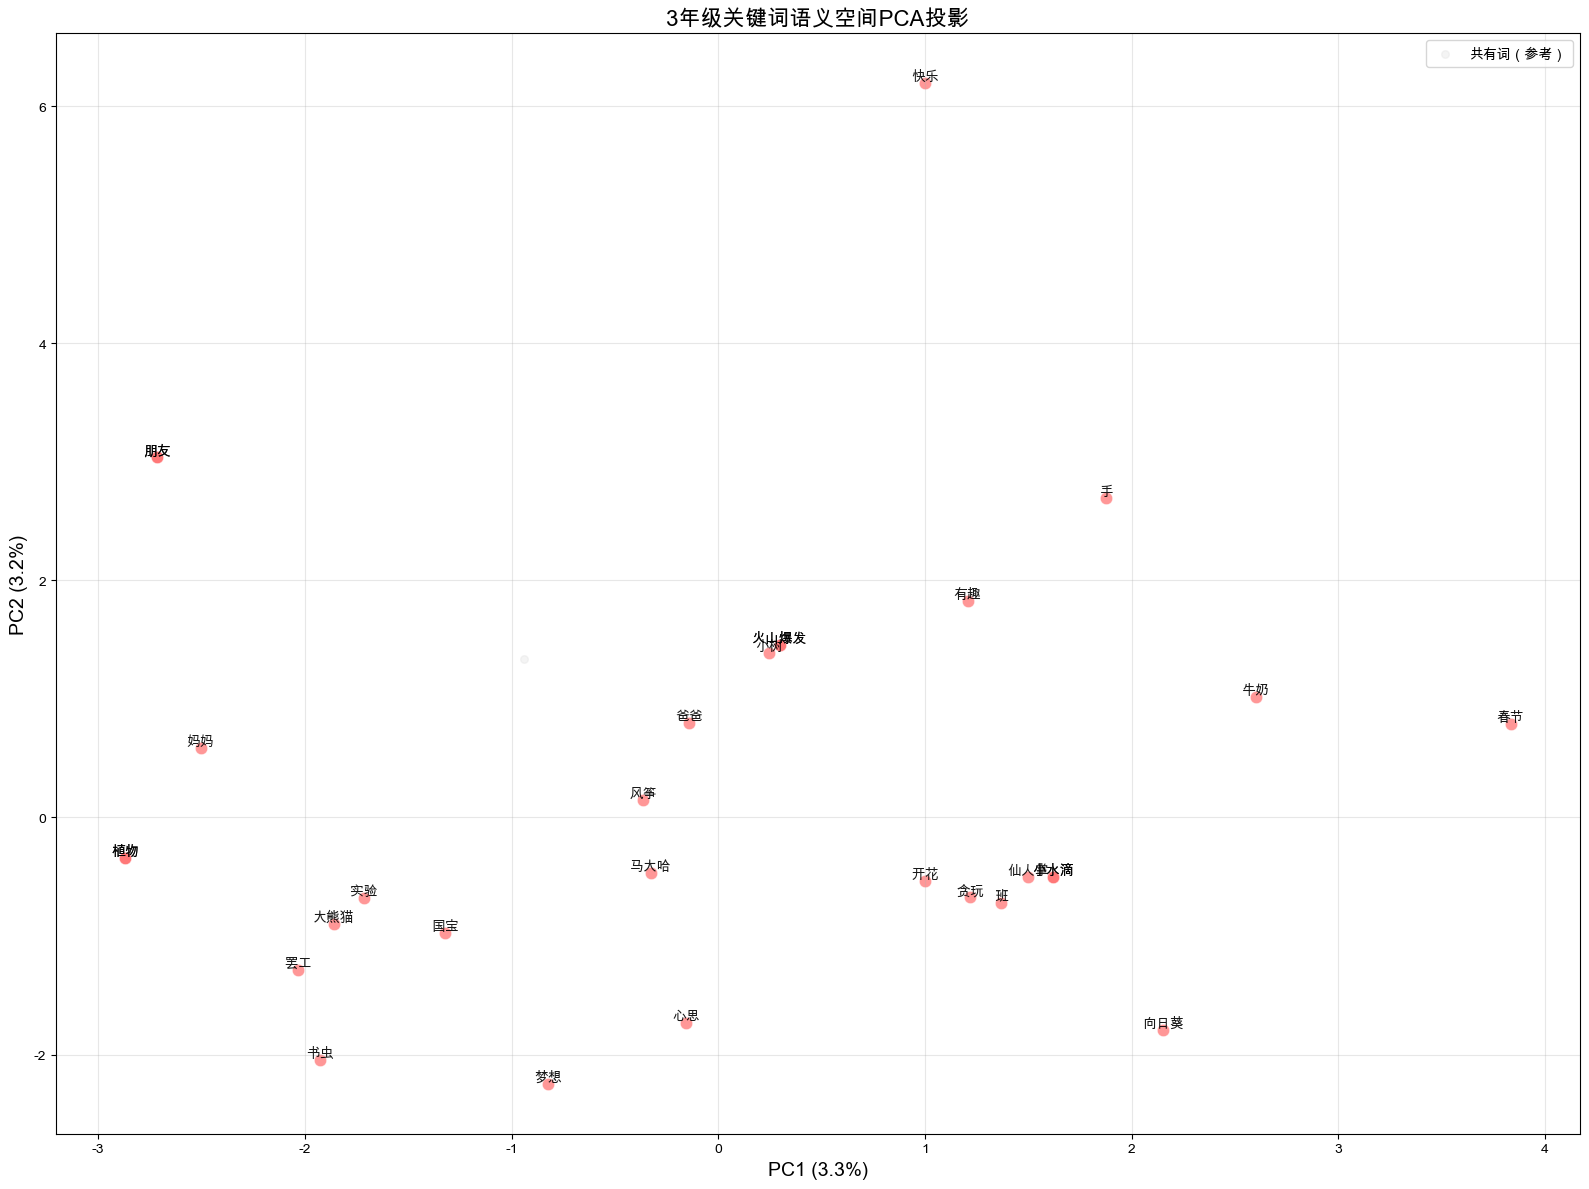

已保存: pca_grade3.png


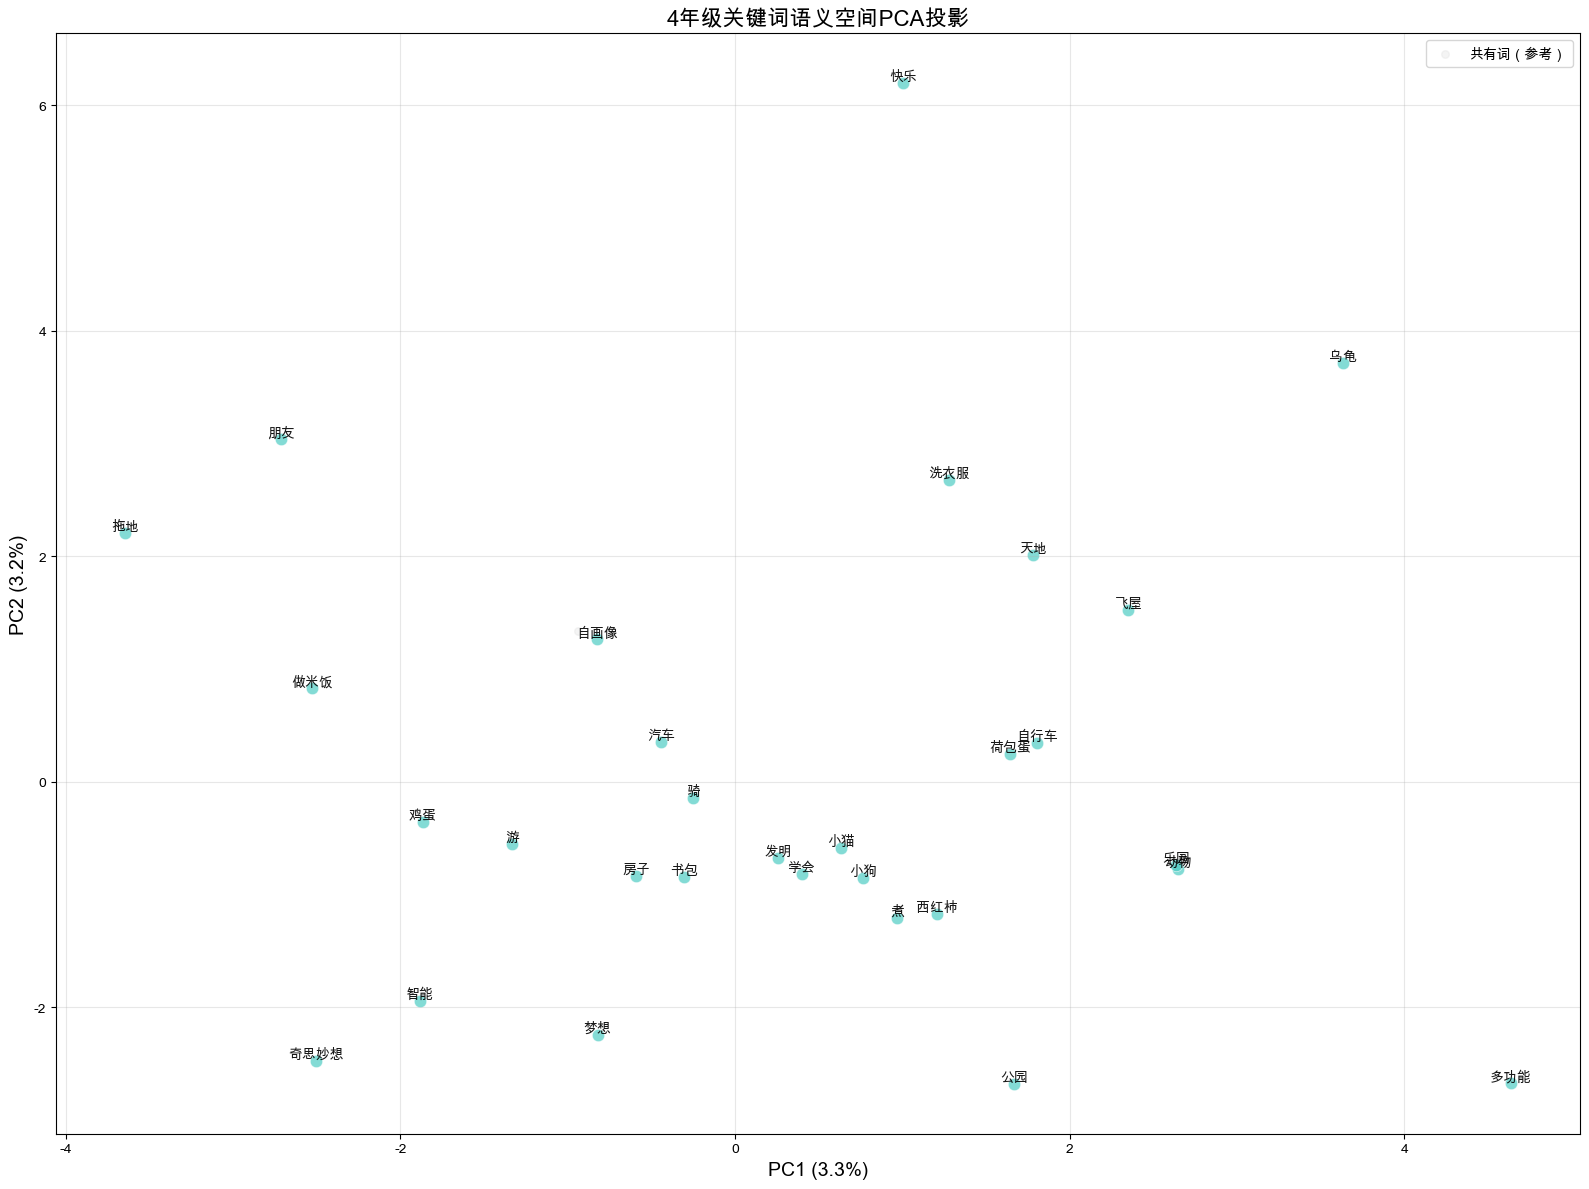

已保存: pca_grade4.png


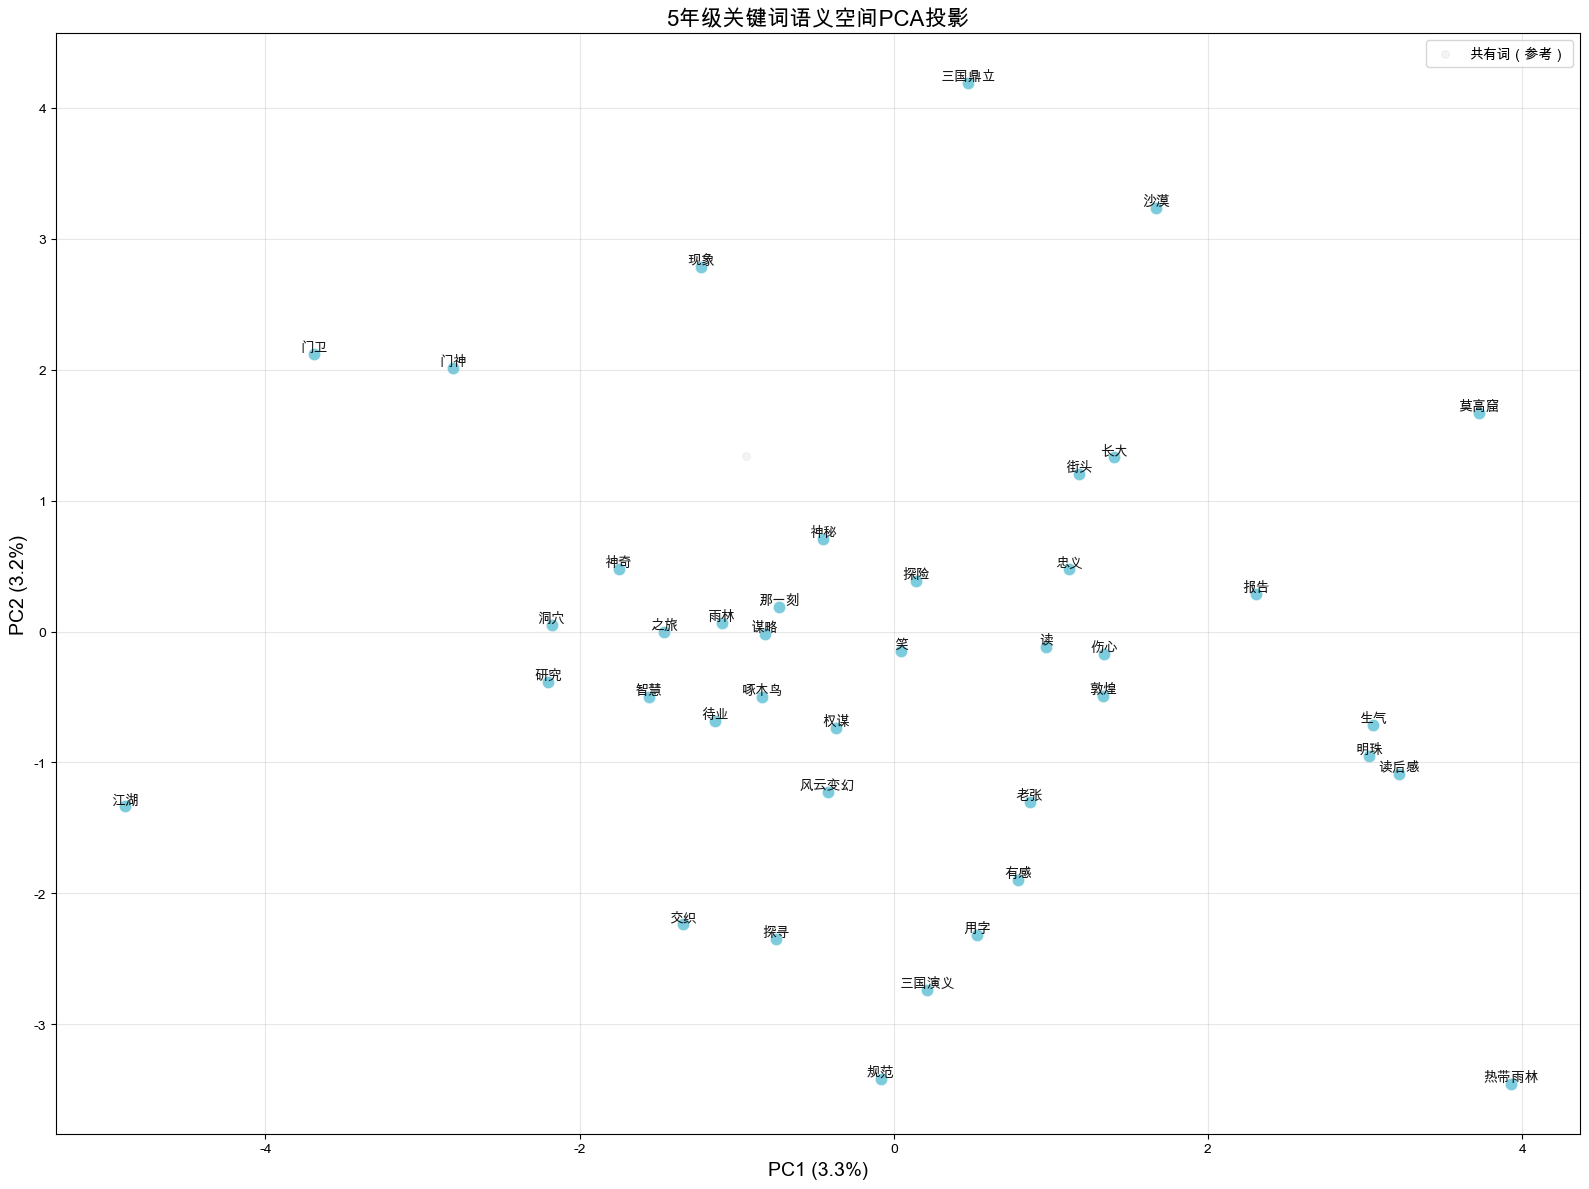

已保存: pca_grade5.png


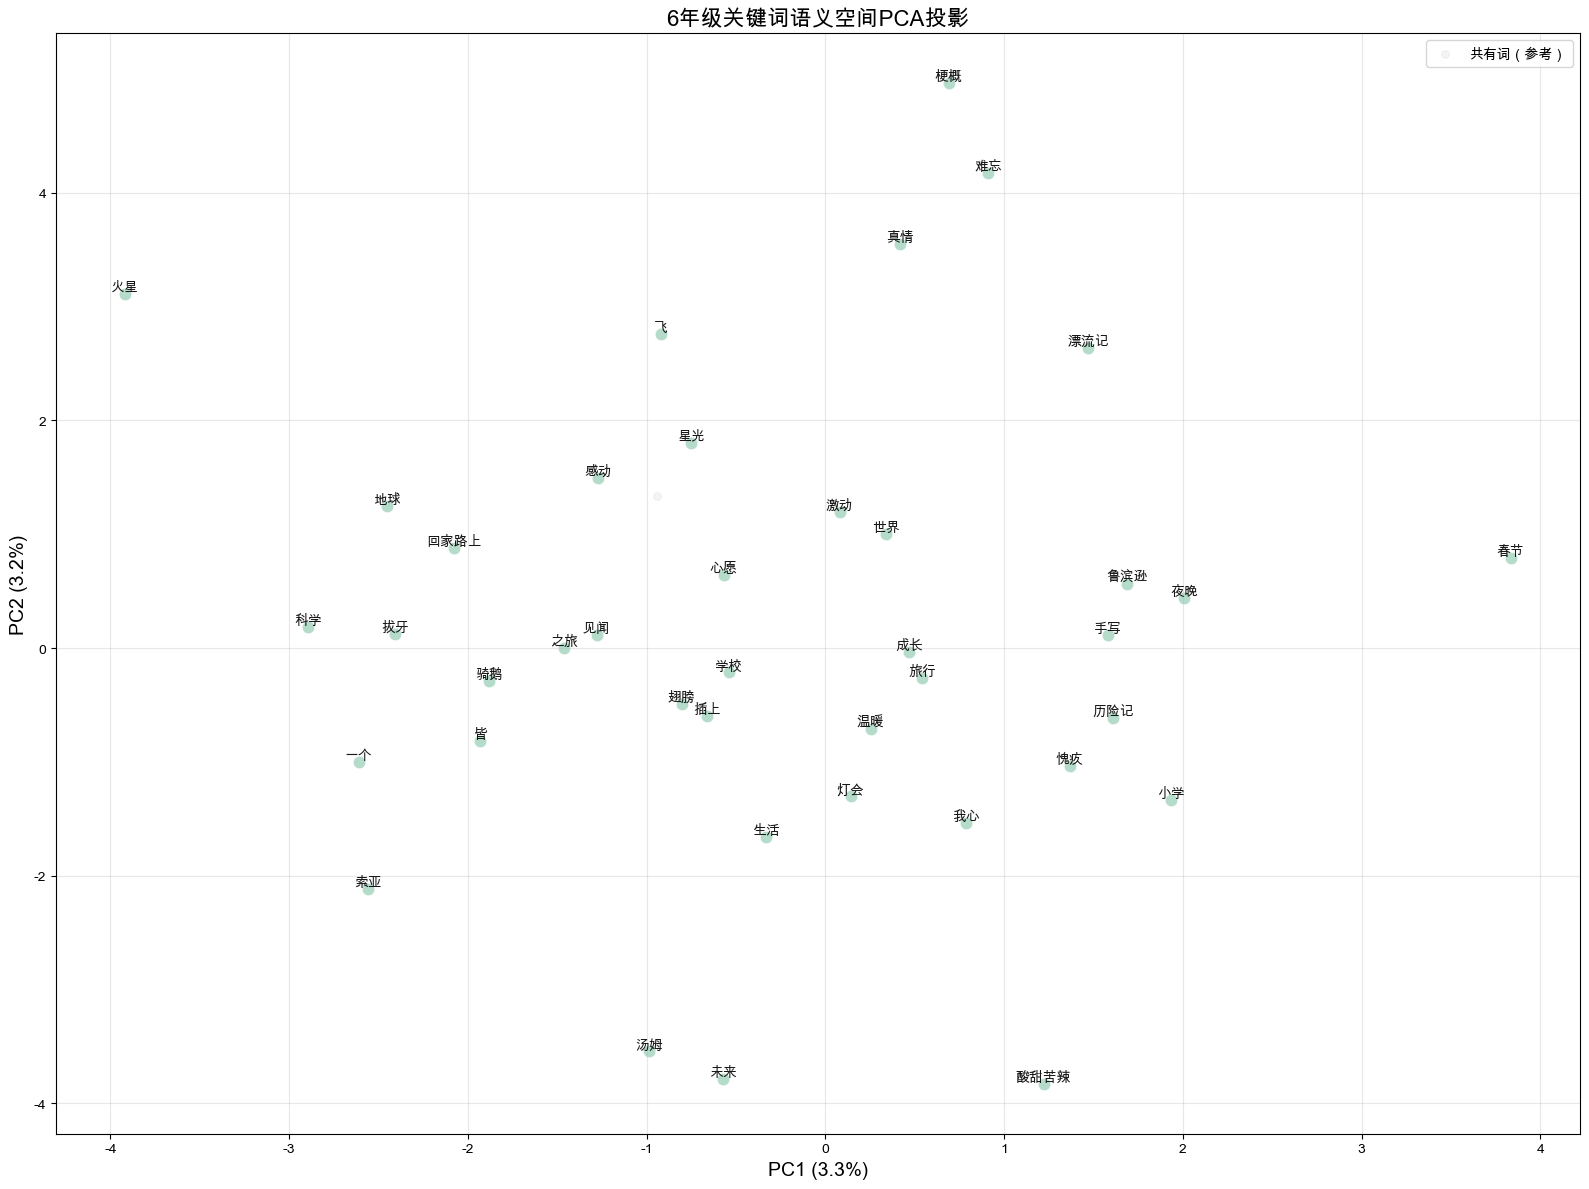

已保存: pca_grade6.png

分析完成！


In [22]:
# 6. 可选：分年级单独投射（每个年级一张图）
# ============================================

print("\n" + "="*60)
print("生成分年级单独投射图...")
print("="*60)

for grade, grade_word_list in [(3, grade3_words), (4, grade4_words), (5, grade5_words), (6, grade6_words)]:
    # 获取该年级的词
    grade_words_valid = [w for w in grade_word_list if w in valid_words]
    grade_indices = [valid_words.index(w) for w in grade_words_valid]
    
    if len(grade_indices) < 2:
        print(f"{grade}年级有效词不足，跳过")
        continue
    
    x = pca_result[grade_indices, 0]
    y = pca_result[grade_indices, 1]
    
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # 绘制该年级的词
    ax.scatter(x, y, c=grade_colors[grade], s=80, alpha=0.7, edgecolors='white', linewidth=0.5)
    
    # 添加标签
    for word, xi, yi in zip(grade_words_valid, x, y):
        ax.annotate(word, (xi, yi), fontsize=10, alpha=0.9, ha='center', va='bottom')
    
    # 也绘制共有词作为背景参考（可选）
    common_indices = [valid_words.index(w) for w in valid_words if word_grade.get(w, 0) == 0]
    if common_indices:
        x_common = pca_result[common_indices, 0]
        y_common = pca_result[common_indices, 1]
        ax.scatter(x_common, y_common, c='#DDDDDD', s=30, alpha=0.3, label='共有词（参考）')
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=14)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=14)
    ax.set_title(f'{grade}年级关键词语义空间PCA投影', fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(f'pca_grade{grade}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"已保存: pca_grade{grade}.png")

print("\n" + "="*60)
print("分析完成！")
print("="*60)

# ============================================

In [23]:
# 7. 输出各年级中心点坐标
# ============================================

print("\n各年级中心点坐标:")
grade_centers = {}
for grade in [3, 4, 5, 6]:
    grade_words_valid = [w for w in [grade3_words, grade4_words, grade5_words, grade6_words][grade-3] 
                         if w in valid_words]
    grade_indices = [valid_words.index(w) for w in grade_words_valid]
    if grade_indices:
        center = pca_result[grade_indices].mean(axis=0)
        grade_centers[grade] = center
        print(f"  {grade}年级: ({center[0]:.3f}, {center[1]:.3f})")

# 分析年级演变
if 3 in grade_centers and 6 in grade_centers:
    delta = grade_centers[6] - grade_centers[3]
    print(f"\n3年级 → 6年级 整体位移:")
    print(f"  PC1: {'向右' if delta[0] > 0 else '向左'}移动 {abs(delta[0]):.3f}")
    print(f"  PC2: {'向上' if delta[1] > 0 else '向下'}移动 {abs(delta[1]):.3f}")


各年级中心点坐标:
  3年级: (-0.083, 0.274)
  4年级: (0.320, 0.095)
  5年级: (0.038, -0.190)
  6年级: (-0.288, 0.166)

3年级 → 6年级 整体位移:
  PC1: 向左移动 0.206
  PC2: 向下移动 0.108


In [21]:
import gensim
from gensim import corpora
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # To ignore all warnings that arise here to enhance clarity

from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel

In [22]:
from gensim.models import Word2Vec
txt=df['作文标题分词'].apply(lambda X: X.split()).tolist()#切分词语

In [23]:
dictionary = corpora.Dictionary(txt)  # 构建词典
corpus = [dictionary.doc2bow(text) for text in txt]  #表示为第几个单词出现了几次

In [24]:
ldamodel = LdaModel(corpus, num_topics=10, id2word = dictionary, passes=30,random_state = 1)   #分为10个主题
num_topics=10
print(ldamodel.print_topics(num_topics=num_topics, num_words=15)[:20])  #每个主题输出15个单词

[(0, '0.243*"心愿" + 0.081*"快乐" + 0.051*"天地" + 0.029*"成长" + 0.027*"历险记" + 0.026*"探险" + 0.024*"可爱" + 0.022*"洞穴" + 0.022*"书虫" + 0.017*"汤姆" + 0.017*"索亚" + 0.017*"时光" + 0.017*"奇妙" + 0.015*"梗概" + 0.015*"绝唱"'), (1, '0.052*"门神" + 0.045*"爸爸" + 0.044*"多功能" + 0.044*"老张" + 0.042*"马大哈" + 0.034*"房子" + 0.027*"梗概" + 0.024*"班" + 0.021*"牛奶" + 0.020*"王" + 0.020*"开花" + 0.015*"夜晚" + 0.013*"荒岛" + 0.013*"老师" + 0.013*"同学"'), (2, '0.146*"研究" + 0.145*"报告" + 0.142*"规范" + 0.141*"用字" + 0.140*"街头" + 0.125*"现象" + 0.023*"妈妈" + 0.009*"开心" + 0.009*"爱" + 0.005*"唠叨" + 0.004*"鞋" + 0.004*"第一次" + 0.003*"回到" + 0.003*"姐姐" + 0.003*"行走"'), (3, '0.096*"那一刻" + 0.094*"长大" + 0.081*"难忘" + 0.077*"学会" + 0.069*"生活" + 0.069*"小学" + 0.068*"自行车" + 0.064*"骑" + 0.022*"江湖" + 0.021*"义气" + 0.020*"小猫" + 0.018*"玉渊潭公园" + 0.015*"旅行" + 0.014*"豪侠" + 0.014*"发明"'), (4, '0.177*"朋友" + 0.163*"动物" + 0.141*"游" + 0.036*"实验" + 0.035*"大熊猫" + 0.035*"公园" + 0.031*"感动" + 0.027*"国宝" + 0.024*"回家路上" + 0.023*"笑" + 0.023*"星光" + 0.023*"有趣" + 0.020*"西游记" + 0.009*"梦" + 0.0

In [25]:
#计算困惑度
def perplexity(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=15))
    print(ldamodel.log_perplexity(corpus))
    return ldamodel.log_perplexity(corpus)

In [26]:
#计算coherence
def coherence(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30,random_state = 1)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=10))
    ldacm = CoherenceModel(model=ldamodel, texts=txt, dictionary=dictionary, coherence='c_v')
    print(ldacm.get_coherence())
    return ldacm.get_coherence()

[(0, '0.022*"朋友" + 0.021*"放风筝" + 0.019*"学会" + 0.018*"心愿" + 0.017*"智慧" + 0.017*"交织" + 0.016*"探险" + 0.016*"研究" + 0.016*"报告" + 0.016*"动物"')]
0.6266379532237735
[(0, '0.043*"放风筝" + 0.038*"心愿" + 0.019*"难忘" + 0.017*"生气" + 0.016*"生活" + 0.016*"小学" + 0.016*"有感" + 0.015*"读" + 0.015*"探险" + 0.014*"三国演义"'), (1, '0.042*"朋友" + 0.036*"学会" + 0.033*"智慧" + 0.033*"交织" + 0.031*"研究" + 0.031*"报告" + 0.030*"动物" + 0.030*"规范" + 0.030*"用字" + 0.030*"街头"')]
0.6360681559288662
[(0, '0.057*"心愿" + 0.028*"难忘" + 0.026*"生气" + 0.024*"生活" + 0.024*"小学" + 0.024*"有感" + 0.023*"读" + 0.021*"三国演义" + 0.019*"快乐" + 0.017*"春节"'), (1, '0.061*"朋友" + 0.053*"学会" + 0.049*"智慧" + 0.048*"交织" + 0.046*"探险" + 0.044*"动物" + 0.039*"游" + 0.033*"谋略" + 0.033*"小树" + 0.031*"梦想"'), (2, '0.065*"放风筝" + 0.051*"研究" + 0.050*"报告" + 0.049*"规范" + 0.049*"用字" + 0.049*"街头" + 0.043*"现象" + 0.033*"那一刻" + 0.033*"长大" + 0.031*"哭"')]
0.6280729274074202
[(0, '0.079*"心愿" + 0.036*"生气" + 0.034*"有感" + 0.032*"读" + 0.030*"三国演义" + 0.026*"快乐" + 0.023*"春节" + 0.017*"读后感" + 0.017*"天

0.6273183830183907
[(0, '0.414*"心愿" + 0.037*"书虫" + 0.028*"时光" + 0.028*"奇妙" + 0.022*"乌龟" + 0.021*"瞬间" + 0.018*"害怕" + 0.017*"形形色色" + 0.016*"仙人掌" + 0.016*"幸福"'), (1, '0.078*"门神" + 0.065*"老张" + 0.061*"乘凉" + 0.039*"成长" + 0.036*"书包" + 0.036*"班" + 0.031*"牛奶" + 0.029*"开花" + 0.020*"老师" + 0.019*"同学"'), (2, '0.155*"研究" + 0.155*"报告" + 0.151*"规范" + 0.150*"用字" + 0.150*"街头" + 0.133*"现象" + 0.009*"爱" + 0.005*"唠叨" + 0.005*"飞车" + 0.004*"鞋"'), (3, '0.124*"那一刻" + 0.121*"长大" + 0.104*"难忘" + 0.090*"生活" + 0.089*"小学" + 0.046*"江湖" + 0.027*"义气" + 0.026*"世界" + 0.023*"玉渊潭公园" + 0.021*"水浒传"'), (4, '0.229*"探险" + 0.128*"雨林" + 0.085*"之旅" + 0.058*"神奇" + 0.049*"实验" + 0.043*"感动" + 0.031*"笑" + 0.031*"有趣" + 0.027*"西游记" + 0.023*"洞穴"'), (5, '0.159*"游" + 0.064*"三国鼎立" + 0.059*"风云变幻" + 0.044*"奇思妙想" + 0.043*"未来" + 0.039*"公园" + 0.032*"爸爸" + 0.030*"马大哈" + 0.026*"多功能" + 0.025*"我家"'), (6, '0.207*"小树" + 0.198*"梦想" + 0.101*"乐园" + 0.059*"心思" + 0.046*"妈妈" + 0.027*"发明" + 0.025*"小水滴" + 0.024*"温暖" + 0.016*"贪玩" + 0.013*"红楼梦"'), (7, '0.210*"朋友

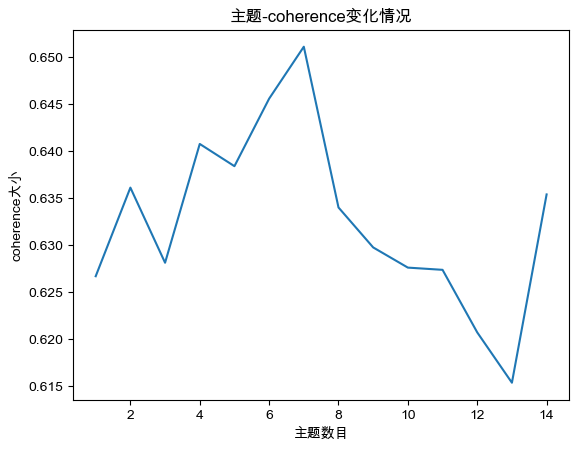

In [27]:
# 绘制困惑度折线图
x = range(1,15)
# z = [perplexity(i) for i in x]
y = [coherence(i) for i in x]
plt.plot(x, y)
plt.xlabel('主题数目')
plt.ylabel('coherence大小')
plt.rcParams['font.sans-serif']=['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus']=False
plt.title('主题-coherence变化情况')
plt.show()

In [28]:
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, passes = 30,random_state=1)
topic_list=lda.print_topics()
print(topic_list[:20])

[(0, '0.106*"心愿" + 0.049*"生气" + 0.045*"有感" + 0.043*"读" + 0.035*"快乐" + 0.031*"春节" + 0.027*"植物" + 0.027*"三国演义" + 0.022*"天地" + 0.018*"梗概"'), (1, '0.100*"智慧" + 0.098*"交织" + 0.079*"游" + 0.068*"谋略" + 0.053*"自画像" + 0.027*"权谋" + 0.022*"读后感" + 0.020*"公园" + 0.019*"门神" + 0.016*"爸爸"'), (2, '0.097*"放风筝" + 0.076*"研究" + 0.076*"报告" + 0.074*"规范" + 0.073*"用字" + 0.073*"街头" + 0.065*"现象" + 0.046*"哭" + 0.037*"智能" + 0.028*"沙漠"'), (3, '0.094*"学会" + 0.053*"那一刻" + 0.052*"长大" + 0.045*"难忘" + 0.038*"生活" + 0.038*"小学" + 0.038*"自行车" + 0.035*"骑" + 0.028*"三国鼎立" + 0.026*"风云变幻"'), (4, '0.101*"朋友" + 0.076*"探险" + 0.073*"动物" + 0.054*"小树" + 0.051*"梦想" + 0.042*"雨林" + 0.028*"之旅" + 0.026*"乐园" + 0.019*"神奇" + 0.018*"奇思妙想"')]


In [29]:
result_list =[]
for i in lda.get_document_topics(corpus)[:]:
    listj=[]
    for j in i:
        listj.append(j[1])
    bz=listj.index(max(listj))
    result_list.append(i[bz][0])
print(result_list[:20])

[1, 0, 1, 4, 3, 3, 1, 2, 2, 2, 1, 0, 0, 1, 4, 0, 3, 3, 4, 3]


In [30]:
import pyLDAvis.gensim
pyLDAvis.enable_notebook()
data = pyLDAvis.gensim.prepare(lda, corpus, dictionary)
pyLDAvis.save_html(data, '全部作文标题.html')

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA